# Dynamic Time-Series Systems & Predictive ODE Engines
**Engineer:** Rasha Quadri  
**Core Stack:** Julia (PyPlot, LinearAlgebra)

## Module 1: Single-Step Linear Time-Series Integration (Euler's Framework)

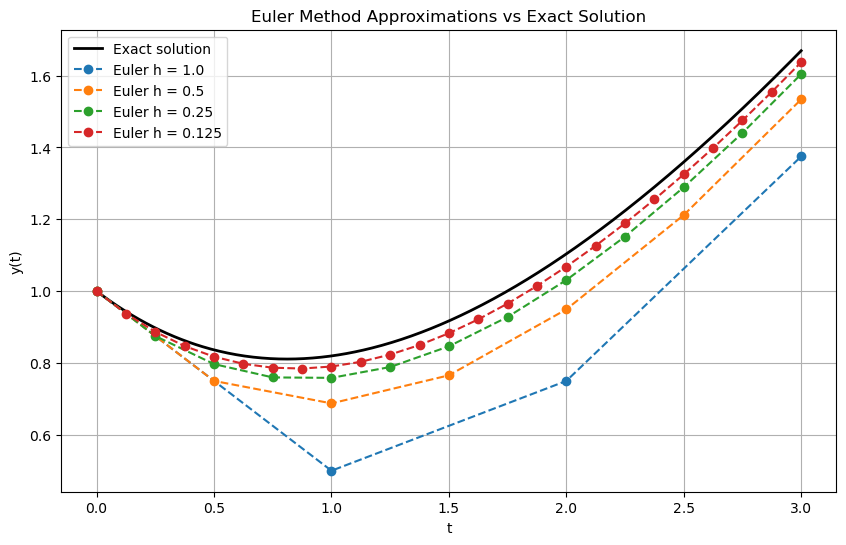

In [14]:
using PyPlot

function eulermethod(f, a, b, u_0, n)
    h = (b-a)/n
    t = range(a, b, n+1)
    u = zeros(n+1)
    u[1] = u_0
    for i in 1:n
        u[i+1] = u[i] + f(t[i], u[i])*h
    end
    return (t, u)
end

f(t, y) = (t - y)/2

y_exact(t) = 3*exp(-t/2) - 2 + t

a = 0.0
b = 3.0
u_0 = 1.0

h_values = [1.0, 0.5, 0.25, 0.125]

t_fine = range(a, b, length=500)
y_fine = y_exact.(t_fine)

figure(figsize=(10,6))
plot(t_fine, y_fine, "k", linewidth=2, label="Exact solution")

for h in h_values
    n = Int((b - a)/h)
    t, U = eulermethod(f, a, b, u_0, n)
    plot(t, U, marker="o", linestyle="--", label="Euler h = $h")
end

title("Euler Method Approximations vs Exact Solution")
xlabel("t")
ylabel("y(t)")
legend()
grid(true)

### Convergence & Local Truncation Diagnostics
The graph isolates step-size sensitivity profiles ($h = 1.0, 0.5, 0.25, 0.125$) against the system's analytical exact curve.

* **Step Distortion Bounds ($h = 1.0$):** When the step size is relatively large, the approximation shows a noticeable deviation from the exact solution, indicating a higher level of accumulated numerical error. Because Euler's method relies on a localized linear tangent approximation at each step, it cannot perfectly capture the underlying curvature of the true solution over large steps.
* **Asymptotic Convergence ($h \rightarrow 0.125$):** As the step size decreases, the approximations become increasingly accurate. The curves for $h = 0.25$ and $h = 0.125$ track the exact solution closely across the entire interval $(0, 3)$. Reducing the step size forces the system to re-evaluate the changing slope more frequently, effectively dampening local truncation error and driving global error down to zero.

# Assignment 2

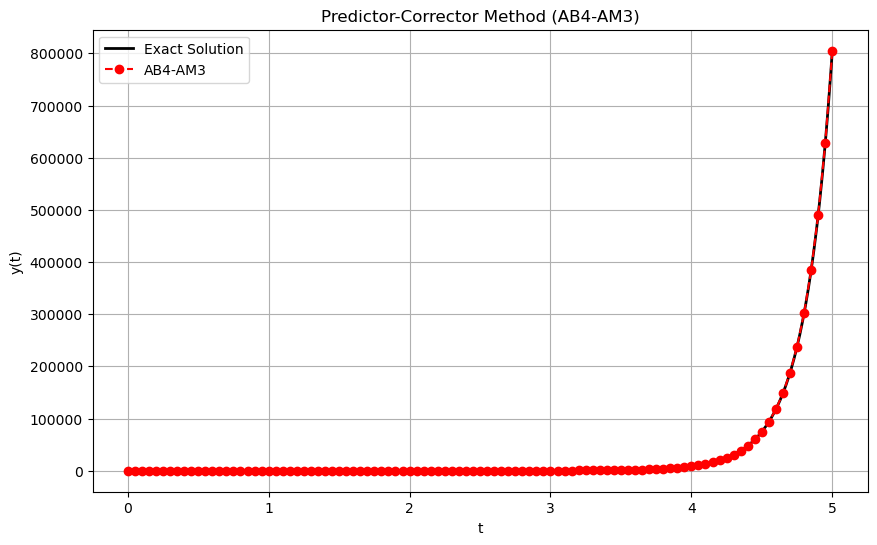

In [16]:
using PyPlot

f(t, y) = t*y + t^3

function y_exact(t)
    return 3*exp(t^2/2) - (t^2 + 2)
end

function AB4_AM3(f, a, b, y0, h)
    N = Int(round((b - a)/h))
    t = collect(a:h:b)
    w = zeros(N+1)
    w[1] = y0

    for i in 1:3
        k1 = f(t[i], w[i])
        k2 = f(t[i] + h/2, w[i] + h*k1/2)
        k3 = f(t[i] + h/2, w[i] + h*k2/2)
        k4 = f(t[i] + h, w[i] + h*k3)
        w[i+1] = w[i] + (h/6)*(k1 + 2k2 + 2k3 + k4)
    end

    for i in 4:N
        f_i   = f(t[i], w[i])
        f_im1 = f(t[i-1], w[i-1])
        f_im2 = f(t[i-2], w[i-2])
        f_im3 = f(t[i-3], w[i-3])

        w_pred = w[i] + (h/24)*(55*f_i - 59*f_im1 + 37*f_im2 - 9*f_im3)

        f_ip1 = f(t[i+1], w_pred)
        w[i+1] = w[i] + (h/24)*(9*f_ip1 + 19*f_i - 5*f_im1 + f_im2)
    end

    return t, w
end

a = 0.0
b = 5.0
y0 = 1.0
h = 0.05

t_vals, w_vals = AB4_AM3(f, a, b, y0, h)

t_fine = range(a, b, length=500)
y_fine = y_exact.(t_fine)


figure(figsize=(10,6))
plot(t_fine, y_fine, "k", linewidth=2, label="Exact Solution")
plot(t_vals, w_vals, "ro--", label="AB4-AM3")

title("Predictor-Corrector Method (AB4-AM3)")
xlabel("t")
ylabel("y(t)")
legend()
grid(true)

## Results Interpretation


We implemented a predictor–corrector method by combining the Adams–Bashforth four-step (AB4) method as the predictor and the Adams–Moulton three-step (AM3) method as the corrector, using a step size of $h = 0.05$. The method was applied to the initial value problem

$$
y' = ty + t^3, \quad y(0) = 1
$$

on the interval $[0,5]$.

The numerical solution obtained from the AB4–AM3 method closely matches the exact solution throughout the interval. In the plot, the approximation 
(red dashed line with markers) lies almost exactly on top of the exact solution (black solid curve), indicating that the predictor–corrector 
method is highly accurate for this problem.

As $t$ increases, the solution grows very rapidly due to the exponential term in the exact solution,

$$
y(t) = 3e^{t^2/2} - (t^2 + 2),
$$

which dominates the behavior for larger $t$. This causes the graph to appear relatively flat for small values of $t$, followed by a sharp increase 
near $t = 5$.

Despite this rapid growth, the numerical method remains stable and continues to track the exact solution very closely. This demonstrates the 
effectiveness of the predictor–corrector approach, where the Adams–Bashforth method provides an initial estimate and the Adams–Moulton method 
refines it, improving overall accuracy.

Overall, the results confirm that the AB4–AM3 predictor–corrector method provides an accurate approximation to the true solution on the given 
interval with the chosen step size.